In [3]:
%matplotlib inline
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os

In [4]:

file_path = os.path.join('..', 'data', 'raw', 'newsData','raw_analyst_ratings.csv')
news_df=pd.read_csv(file_path)
news_df.head()
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


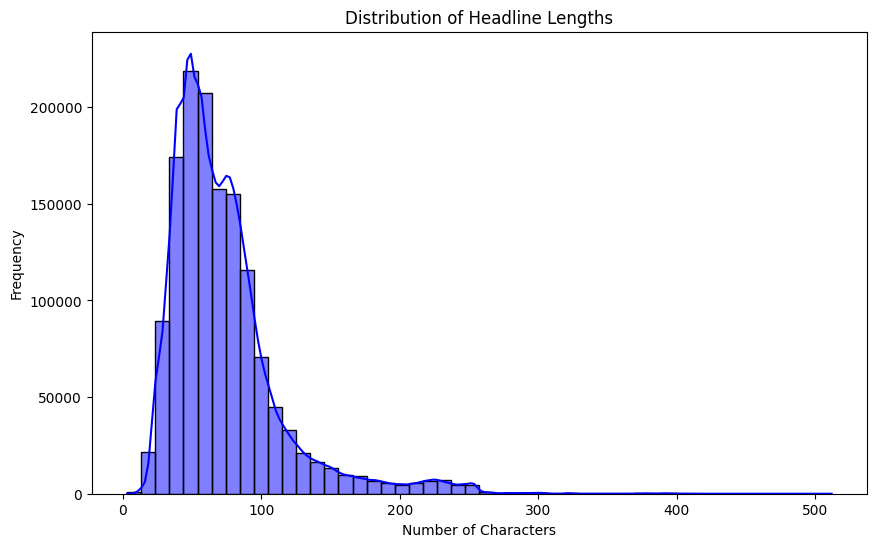

In [5]:
#Descriptive Statistics
#Calculate Headline Lengths
news_df['headline_len'] = news_df['headline'].apply(len)

print("Headline Length Statistics:")
print(news_df['headline_len'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(news_df['headline_len'], bins=50, kde=True, color='blue')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

Top 10 Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


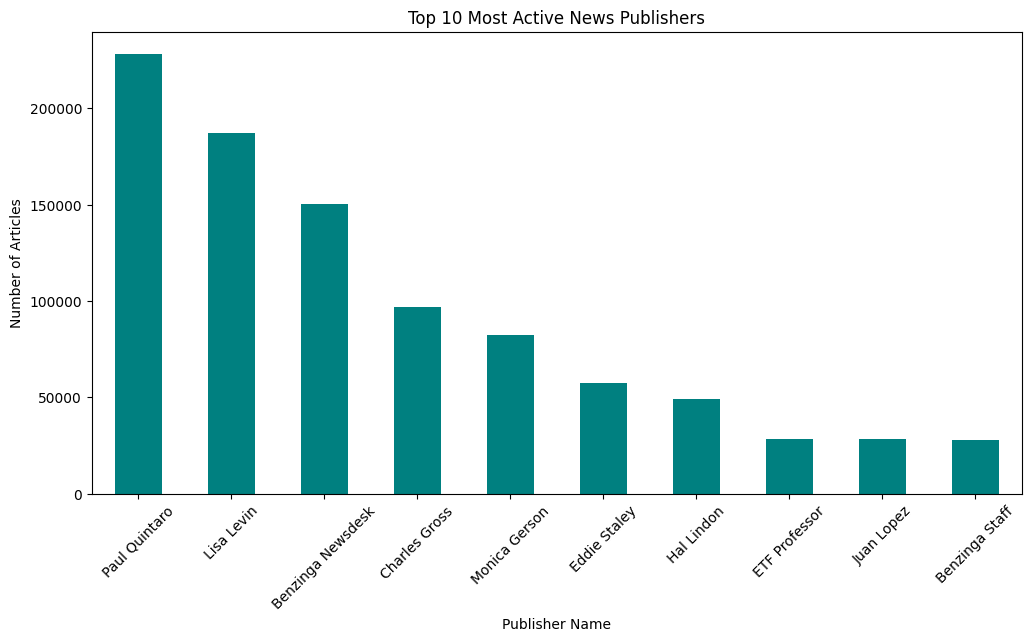

In [6]:
publisher_counts = news_df['publisher'].value_counts()

# 2. Get the top 10 most active publishers
top_10_publishers = publisher_counts.head(10)

print("Top 10 Publishers:")
print(top_10_publishers)

plt.figure(figsize=(12, 6))
top_10_publishers.plot(kind='bar', color='teal')
plt.title('Top 10 Most Active News Publishers')
plt.xlabel('Publisher Name')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

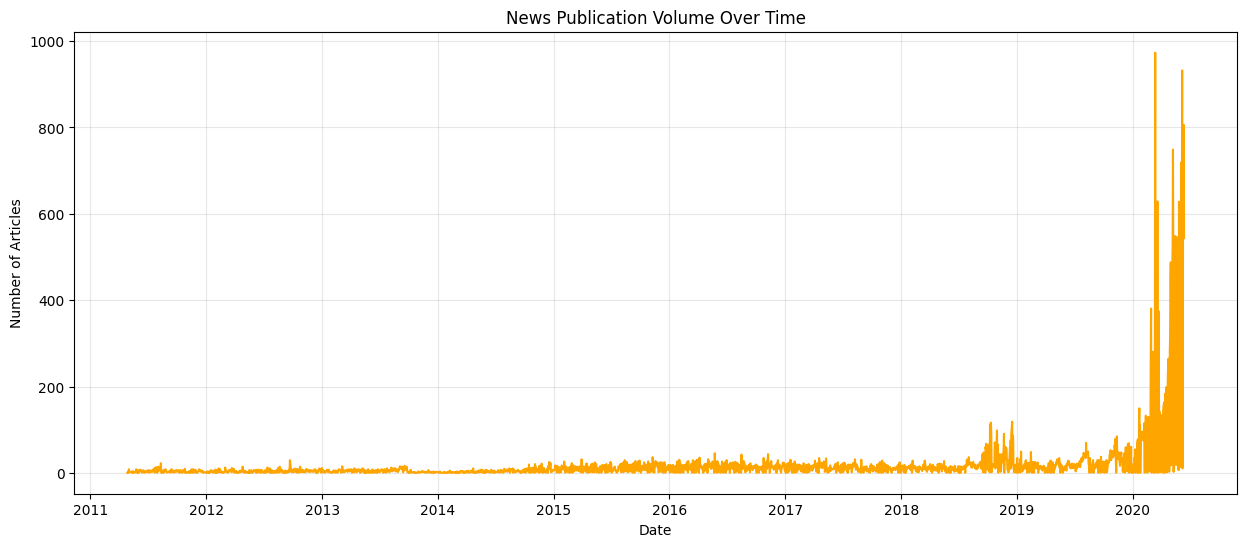

In [7]:
# 1. Convert the 'date' column to datetime objects
# Note: errors='coerce' turns unparseable dates into NaT (Not a Time)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

# 2. Remove rows where the date couldn't be parsed (if any)
news_df = news_df.dropna(subset=['date'])

# 3. Extract just the date (ignoring the time) to see daily volume
news_df['only_date'] = news_df['date'].dt.date
daily_news_counts = news_df.groupby('only_date').size()

# 4. Visualize the News Volume Spike over time
plt.figure(figsize=(15, 6))
daily_news_counts.plot(kind='line', color='orange')
plt.title('News Publication Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
#Text Analysis (Topic Modeling)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# For CountVectorizer and TF-IDF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# For LDA (Topic Modeling)
from sklearn.decomposition import LatentDirichletAllocation

[nltk_data] Downloading package stopwords to /home/sifen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/sifen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/sifen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
#cleaning word
import sys
sys.path.append('../scripts') 

from helper import clean_headline

news_df['cleaned_headline'] = news_df['headline'].apply(clean_headline)
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_len,only_date,cleaned_headline
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39,2020-06-05,stocks hit week highs friday
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42,2020-06-03,stocks hit week highs wednesday
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29,2020-05-26,biggest movers friday
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44,2020-05-22,stocks moving fridays midday session
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87,2020-05-22,b securities maintains neutral agilent technol...


In [10]:
#CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
cv = CountVectorizer(max_features=20)  # top 20 most common words

# Fit and transform the cleaned headlines
cv_matrix = cv.fit_transform(news_df['cleaned_headline'])

# Convert to dataframe to see the results
cv_df = pd.DataFrame(cv_matrix.toarray(), columns=cv.get_feature_names_out())

print(cv_df.head())

   companies  eps  estimate  higher  hit  lows  maintains  market  new  price  \
0          0    0         0       0    1     0          0       0    0      0   
1          0    0         0       0    1     0          0       0    0      0   
2          0    0         0       0    0     0          0       0    0      0   
3          0    0         0       0    0     0          0       0    0      0   
4          0    0         0       0    0     0          1       0    0      1   

   sales  session  several  shares  stocks  target  trading  us  week  \
0      0        0        0       0       1       0        0   0     1   
1      0        0        0       0       1       0        0   0     1   
2      0        0        0       0       0       0        0   0     0   
3      0        1        0       0       1       0        0   0     0   
4      0        0        0       0       0       1        0   0     0   

   yesterday  
0          0  
1          0  
2          0  
3          0  

/tmp/ipykernel_18188/1269892140.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette='Blues_r')


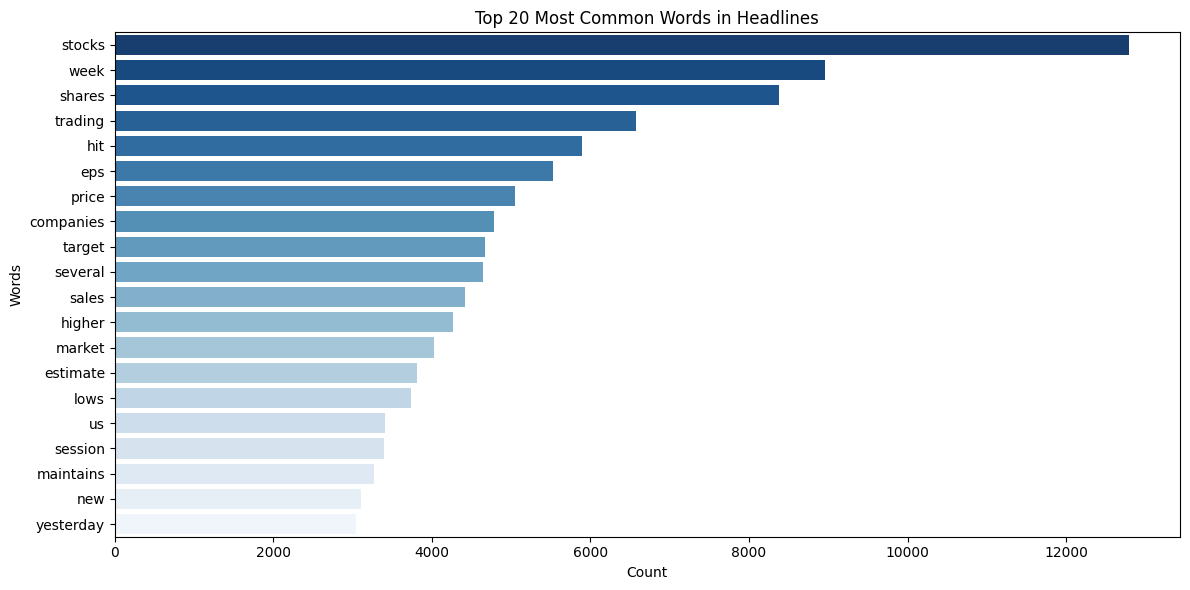

In [11]:
# Sum up how many times each word appears
word_counts = cv_df.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=word_counts.values, y=word_counts.index, palette='Blues_r')
plt.title('Top 20 Most Common Words in Headlines')
plt.xlabel('Count')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

In [12]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=20)  # top 20 important words

# Fit and transform
tfidf_matrix = tfidf.fit_transform(news_df['cleaned_headline'])

# Convert to dataframe
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print(tfidf_df.head())

   companies  eps  estimate  higher      hit  lows  maintains  market  new  \
0        0.0  0.0       0.0     0.0  0.65371   0.0   0.000000     0.0  0.0   
1        0.0  0.0       0.0     0.0  0.65371   0.0   0.000000     0.0  0.0   
2        0.0  0.0       0.0     0.0  0.00000   0.0   0.000000     0.0  0.0   
3        0.0  0.0       0.0     0.0  0.00000   0.0   0.000000     0.0  0.0   
4        0.0  0.0       0.0     0.0  0.00000   0.0   0.619025     0.0  0.0   

      price  sales   session  several  shares    stocks    target  trading  \
0  0.000000    0.0  0.000000      0.0     0.0  0.498036  0.000000      0.0   
1  0.000000    0.0  0.000000      0.0     0.0  0.498036  0.000000      0.0   
2  0.000000    0.0  0.000000      0.0     0.0  0.000000  0.000000      0.0   
3  0.000000    0.0  0.838283      0.0     0.0  0.545236  0.000000      0.0   
4  0.549329    0.0  0.000000      0.0     0.0  0.000000  0.561289      0.0   

    us      week  yesterday  
0  0.0  0.569757        0.0  
1 

/tmp/ipykernel_18188/1000770188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tfidf_scores.values, y=tfidf_scores.index, palette='Greens_r')


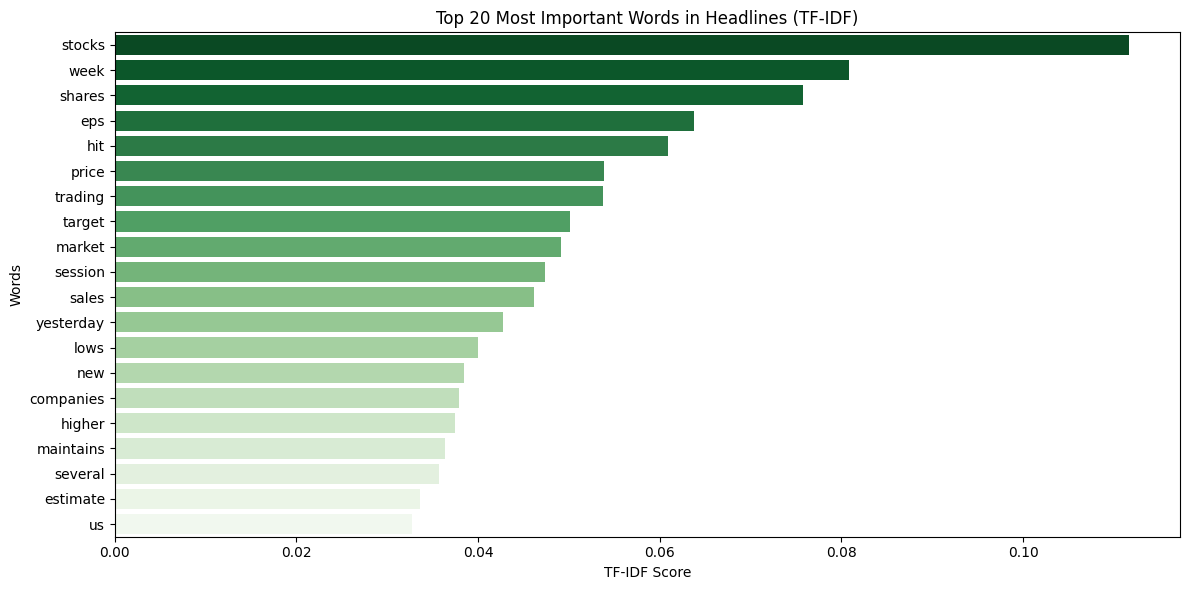

In [13]:
# Average importance score of each word
tfidf_scores = tfidf_df.mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=tfidf_scores.values, y=tfidf_scores.index, palette='Greens_r')
plt.title('Top 20 Most Important Words in Headlines (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

Topic 1: week, stocks, hit, companies, several, market, lows, trading, shares, us

Topic 2: price, target, maintains, market, companies, shares, us, trading, higher, new

Topic 3: eps, sales, estimate, trading, shares, higher, companies, yesterday, new, us

Topic 4: stocks, session, new, yesterday, week, trading, several, companies, shares, us

Topic 5: shares, trading, higher, us, companies, several, sales, market, session, stocks



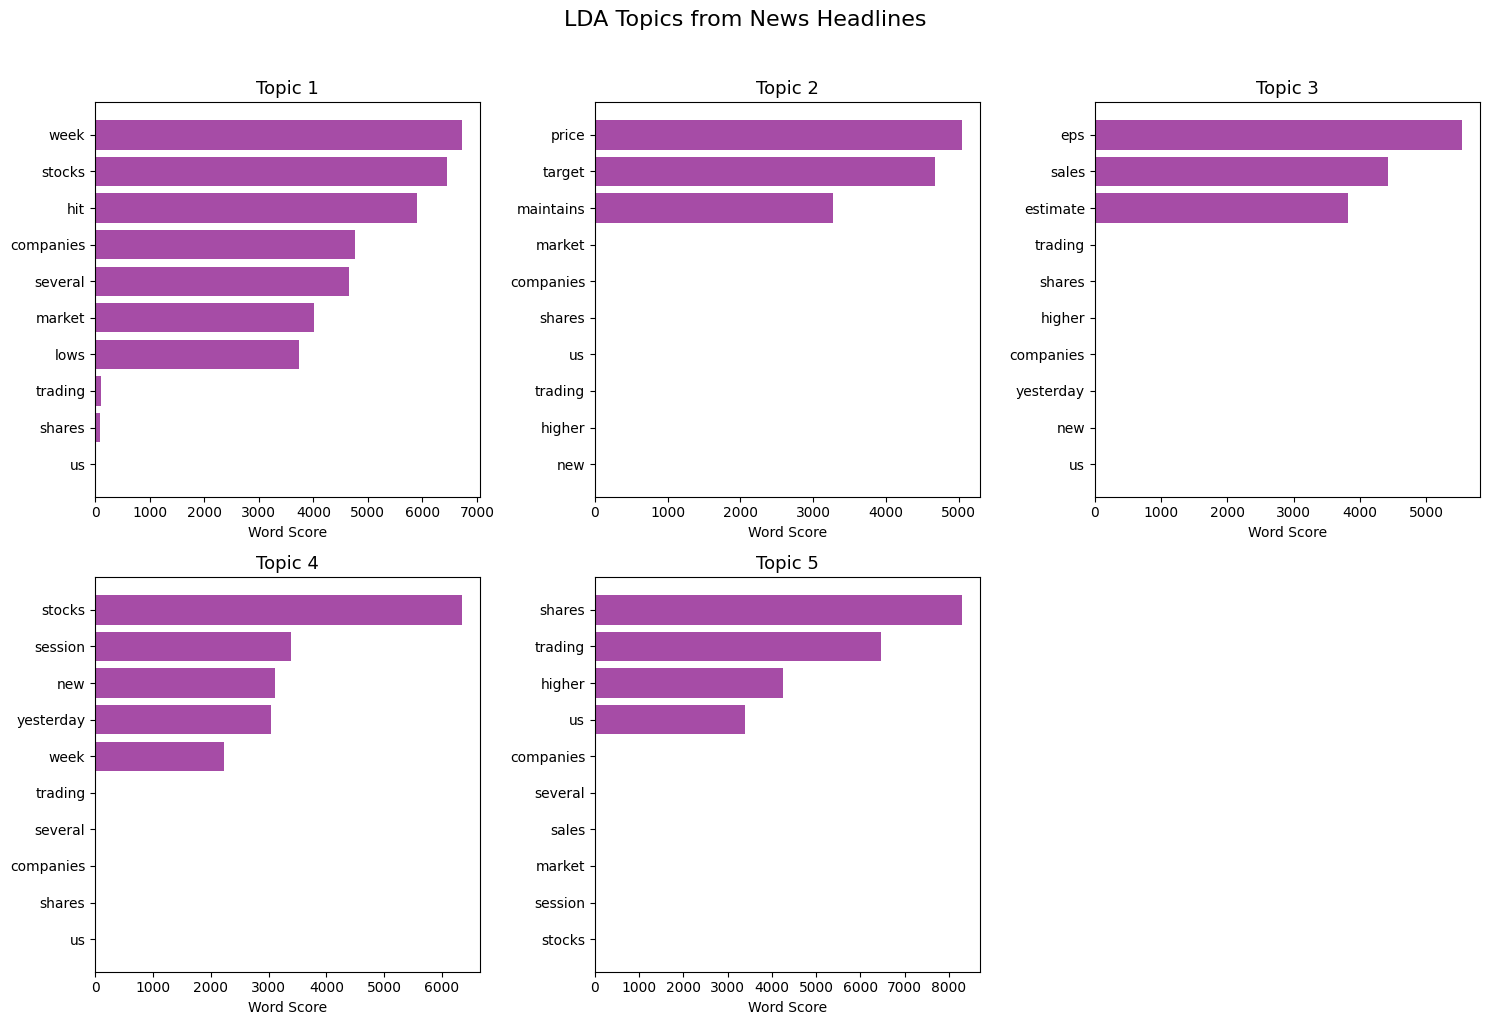

/tmp/ipykernel_18188/1196938366.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dominant_topic', data=news_df, palette='viridis')


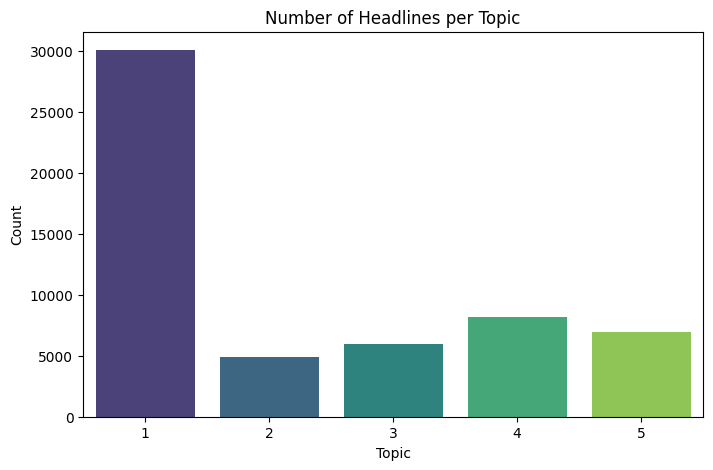


--- Topic 1 Sample Headlines ---
0       Stocks That Hit 52-Week Highs On Friday
1    Stocks That Hit 52-Week Highs On Wednesday
2                 71 Biggest Movers From Friday

--- Topic 2 Sample Headlines ---
4    B of A Securities Maintains Neutral on Agilent...
5    CFRA Maintains Hold on Agilent Technologies, L...
6    UBS Maintains Neutral on Agilent Technologies,...

--- Topic 3 Sample Headlines ---
4179    AAC shares are trading lower after the company...
4796    Altisource Asset Mgmt Q1 EPS $2.350 Up From $0...
4798    Altisource Asset Mgmt Q4 EPS $(1) Up From $(2....

--- Topic 4 Sample Headlines ---
3            46 Stocks Moving In Friday's Mid-Day Session
1436    10 Basic Materials Stocks Moving In Friday's P...
1440    5 Basic Materials Stocks Moving In Wednesday's...

--- Topic 5 Sample Headlines ---
7       Agilent Technologies shares are trading higher...
1435    Shares of several basic materials companies ar...
1437    Shares of several basic materials are trading ...

In [14]:
from sklearn.decomposition import LatentDirichletAllocation

# Initialize LDA — we'll find 5 topics
lda = LatentDirichletAllocation(n_components=5, random_state=42)

# Fit on the CountVectorizer matrix (LDA works with word counts)
lda.fit(cv_matrix)

# Function to display top words in each topic
def display_topics(model, feature_names, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")
        print()

# Display topics
feature_names = cv.get_feature_names_out()
display_topics(lda, feature_names)

import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [topic[i] for i in top_indices]

    axes[topic_idx].barh(top_words[::-1], top_scores[::-1], color='purple', alpha=0.7)
    axes[topic_idx].set_title(f'Topic {topic_idx + 1}', fontsize=13)
    axes[topic_idx].set_xlabel('Word Score')

# Hide the extra subplot (we have 5 topics but 6 subplots)
axes[5].set_visible(False)

plt.suptitle('LDA Topics from News Headlines', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Find which topic each headline belongs to
topic_assignments = lda.transform(cv_matrix)
news_df['dominant_topic'] = topic_assignments.argmax(axis=1) + 1  # +1 so topics start at 1

# See the distribution of topics
plt.figure(figsize=(8, 5))
sns.countplot(x='dominant_topic', data=news_df, palette='viridis')
plt.title('Number of Headlines per Topic')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.show()

# Preview headlines per topic
for i in range(1, 6):
    print(f"\n--- Topic {i} Sample Headlines ---")
    print(news_df[news_df['dominant_topic'] == i]['headline'].head(3).to_string())

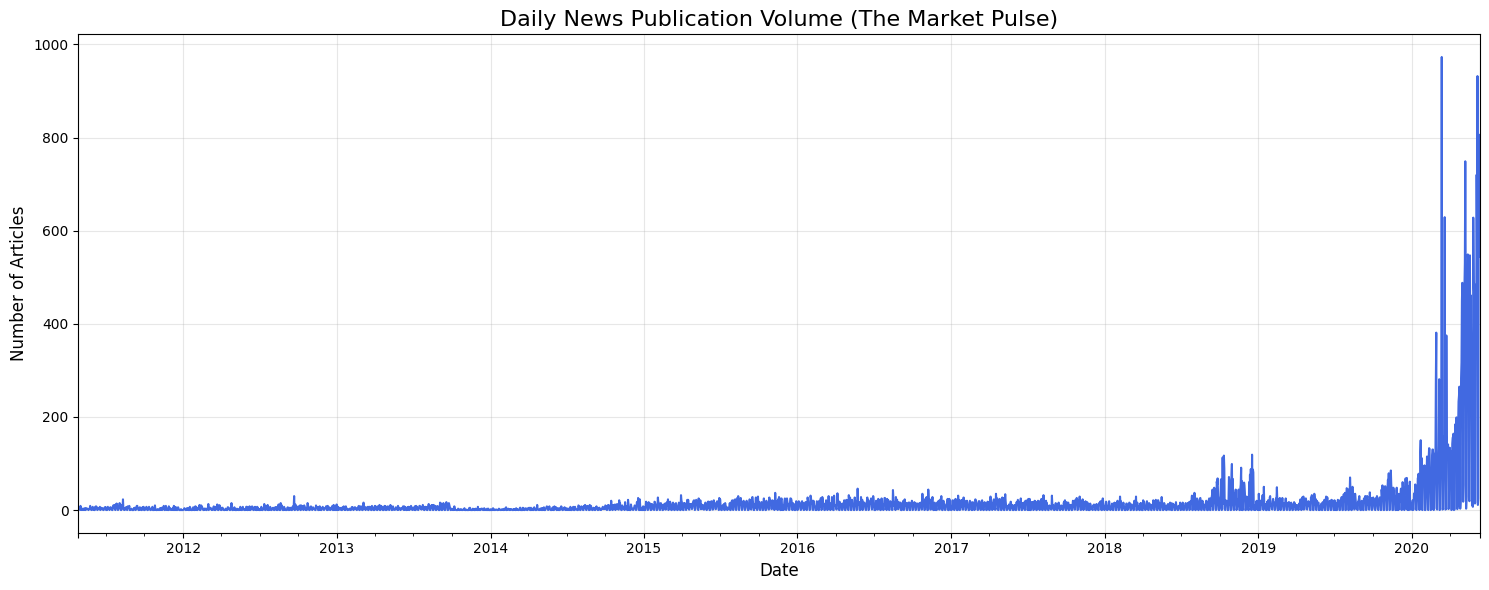

In [15]:
#Time Series Analysis of News Volume

# 1. Ensure the date column is in datetime format
# We use errors='coerce' just in case there are weird strings in your date column
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

# 2. Drop rows where the date is missing (NaT)
news_df = news_df.dropna(subset=['date'])

# 3. Set the date as the index (Required for easy time-series resampling)
news_df.set_index('date', inplace=True)

# 4. Count the number of articles per day
# 'D' stands for Daily. This will count headlines for each calendar day.
daily_news_counts = news_df['headline'].resample('D').count()

# 5. Visualize the "Pulse"

plt.figure(figsize=(15, 6))
daily_news_counts.plot(kind='line', color='royalblue', linewidth=1.5)

# Adding details to make it a professional chart
plt.title('Daily News Publication Volume (The Market Pulse)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Based on the plot 2019 and 2020 shows spike in daily news publication

Top 10 Publishers:
publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64

Top 10 Domains/Organizations:
publisher_domain
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


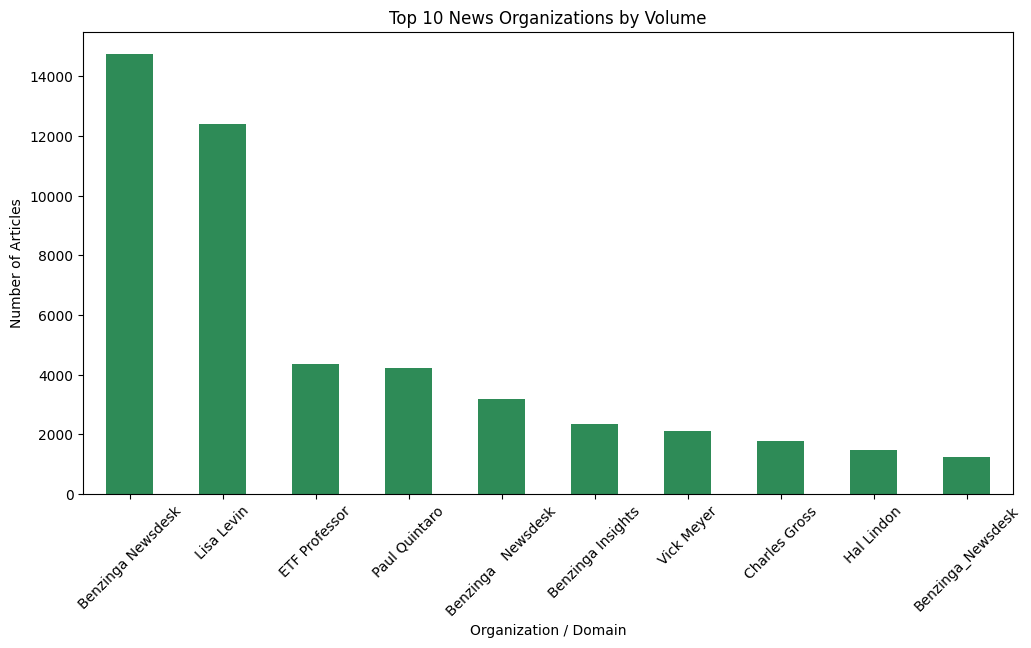

In [16]:
# 1. Count the most active publishers
publisher_counts = news_df['publisher'].value_counts()
print(f"Top 10 Publishers:\n{publisher_counts.head(10)}")

# 2. Extract Domains from Email addresses
# We check if the publisher name looks like an email using a simple string operation
def extract_domain(publisher):
    if '@' in str(publisher):
        return publisher.split('@')[-1]
    return publisher

# Create a new column for the organization/domain
news_df['publisher_domain'] = news_df['publisher'].apply(extract_domain)

# 3. Analyze the new domains
domain_counts = news_df['publisher_domain'].value_counts()
print(f"\nTop 10 Domains/Organizations:\n{domain_counts.head(10)}")

# 4. Visualize the Top 10 Domains
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
domain_counts.head(10).plot(kind='bar', color='seagreen')
plt.title('Top 10 News Organizations by Volume')
plt.xlabel('Organization / Domain')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()